In [3]:
import os; 
print(os.getcwd())

d:\naipunyam_projects\Road_Accident_Severity\notebooks


In [14]:
#data loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import zipfile

zip_path = "../data/raw/Accidents(16-23).zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())

['Accidents(16-23).csv']


In [16]:

with zipfile.ZipFile(zip_path) as z:
    with z.open('Accidents(16-23).csv') as f:
        df = pd.read_csv(f, nrows=100000)

In [17]:
df.shape

(100000, 46)

In [18]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1969646,Source2,2,2019-07-16 17:19:17,2019-07-16 18:56:36,39.749820,-86.278360,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-5480409,Source1,2,2021-03-01 14:08:00.000000000,2021-03-01 15:45:30.000000000,34.168865,-118.594185,34.168583,-118.59243,0.102,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-972405,Source2,3,2021-07-10 14:46:31,2021-07-10 15:13:48,32.720860,-96.827370,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-6727135,Source1,2,2020-10-28 15:26:59,2020-10-28 18:52:19,40.648460,-111.938910,40.648006,-111.93873,0.033,...,False,True,False,False,False,False,Day,Day,Day,Day
4,A-210484,Source2,3,2016-10-04 15:28:11,2016-10-04 16:26:00,41.008330,-73.697780,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                55922 non-null   float64
 8   End_Lng                55922 non-null   float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 99860 non-null   object 
 12  City                   99998 non-null   object 
 13  County                 100000 non-null  object 
 14  State                  100000 non-nul

In [20]:
df.isnull().sum()

ID                           0
Source                       0
Severity                     0
Start_Time                   0
End_Time                     0
Start_Lat                    0
Start_Lng                    0
End_Lat                  44078
End_Lng                  44078
Distance(mi)                 0
Description                  0
Street                     140
City                         2
County                       0
State                        0
Zipcode                     27
Country                      0
Timezone                    97
Airport_Code               282
Weather_Timestamp         1544
Temperature(F)            2105
Wind_Chill(F)            25692
Humidity(%)               2249
Pressure(in)              1792
Visibility(mi)            2251
Wind_Direction            2241
Wind_Speed(mph)           7354
Precipitation(in)        28433
Weather_Condition         2202
Amenity                      0
Bump                         0
Crossing                     0
Give_Way

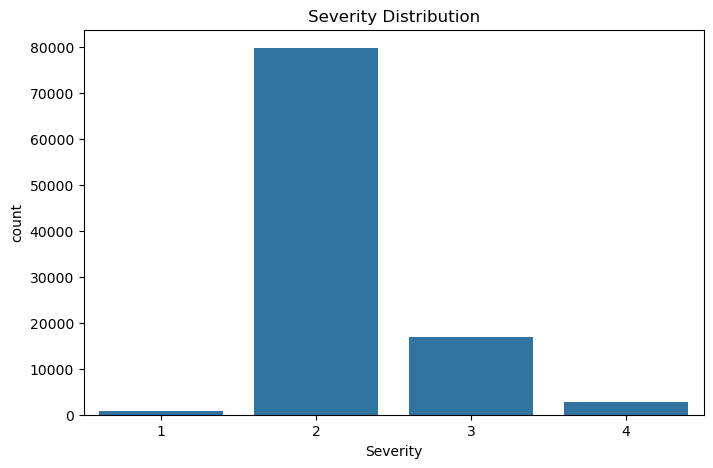

In [21]:
#Severity distribution
plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title("Severity Distribution")

plt.show()

In [22]:
#Accidents by hour

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='ISO8601')
df['Hour'] = df['Start_Time'].dt.hour

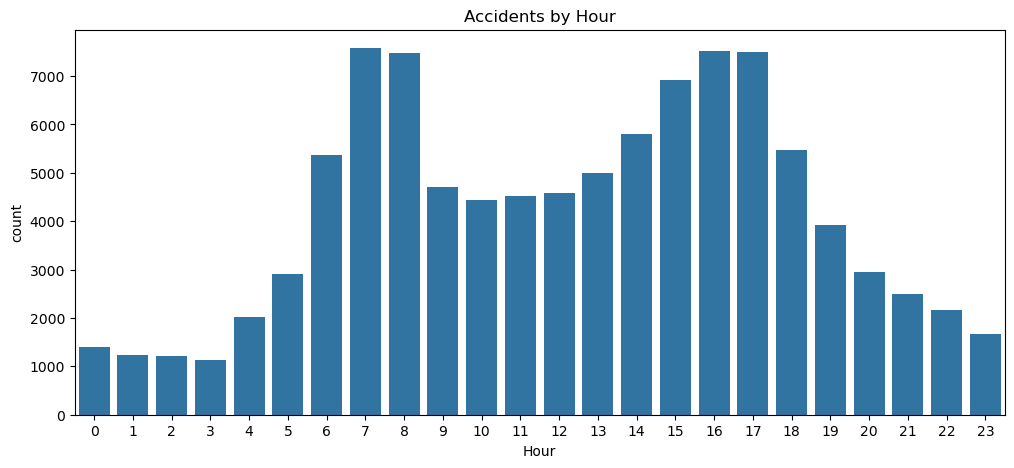

In [23]:
plt.figure(figsize=(12,5))

sns.countplot(x='Hour', data=df)

plt.title("Accidents by Hour")

plt.show()

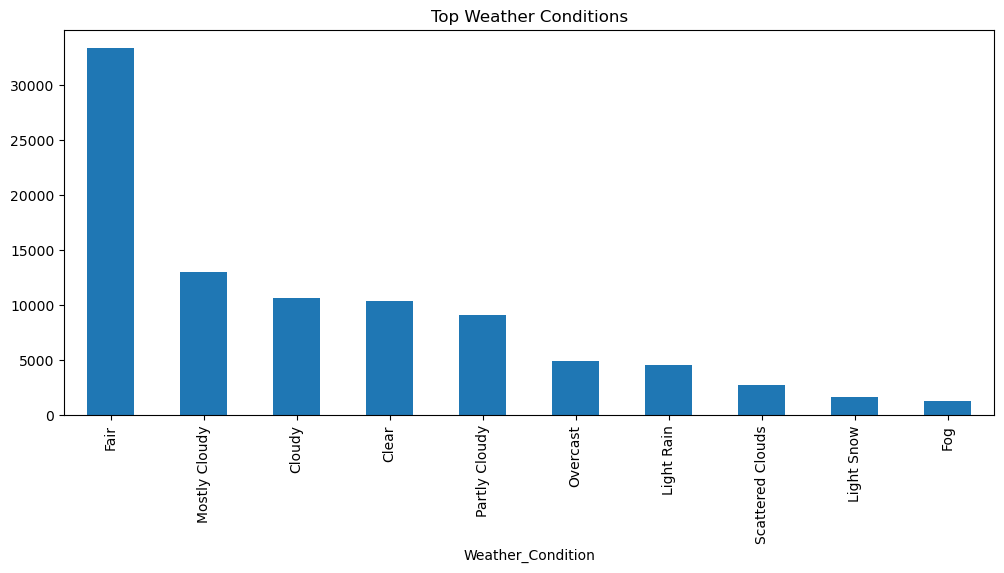

In [24]:
# Top waether conditions
top_weather = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(12,5))

top_weather.plot(kind='bar')

plt.title("Top Weather Conditions")

plt.show()